In [1]:
import os
import sys
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.append(project_root)

from src.config import *
from src.environment import HotelPricingEnv
from src.dqn_agent import DQNAgent

In [2]:
env = HotelPricingEnv()

agent = DQNAgent(state_size=2,action_size=len(PRICE_LEVELS),learning_rate=0.001,gamma=0.99,epsilon=0,
                 epsilon_min=0.05,epsilon_decay=0.998,memory_size=20000,batch_size=128)

agent.model.load_state_dict(torch.load("../models/dqn_model.pth"))
agent.model.eval()

print("Trained DQN model loaded successfully.")

Trained DQN model loaded successfully.


In [3]:
SIMULATIONS = 1000

evaluation_results = []

In [4]:
for season in range(1, SIMULATIONS + 1):
    state, info = env.reset()
    done = False
    total_revenue = 0
    total_rooms = 0
    total_price = 0
    decisions = 0

    while not done:
        action = agent.select_action(state)
        price = PRICE_LEVELS[action]
        next_state, reward, done, _, info = env.step(action)

        total_revenue += reward
        total_rooms += info["rooms_sold"]
        total_price += price
        decisions += 1

        state = next_state

    occupancy = (total_rooms / TOTAL_ROOMS) * 100

    evaluation_results.append({
        "Season": season,
        "Revenue": total_revenue,
        "Rooms Sold": total_rooms,
        "Occupancy (%)": occupancy,
        "Average Price": total_price / decisions
    })

In [5]:
evaluation_results = pd.DataFrame(evaluation_results)

evaluation_results.head()

,Season,Revenue,Rooms Sold,Occupancy (%),Average Price
0,1,3255,37,74.0,118.666667
1,2,2570,30,60.0,118.666667
2,3,3840,48,96.0,114.000000
3,4,3440,40,80.0,114.666667
4,5,2800,32,64.0,118.666667


In [6]:
summary = pd.DataFrame({
    "Metric":["Average Revenue",
              "Average Rooms Sold",
              "Average Occupancy (%)",
              "Average Price"],
    "Value":[evaluation_results["Revenue"].mean(),
             evaluation_results["Rooms Sold"].mean(),
             evaluation_results["Occupancy (%)"].mean(),
             evaluation_results["Average Price"].mean()]
})
summary

,Metric,Value
0,Average Revenue,3384.610000
1,Average Rooms Sold,39.702000
2,Average Occupancy (%),79.404000
3,Average Price,117.836118


In [7]:
summary.describe

<bound method NDFrame.describe of                   Metric        Value
0        Average Revenue  3384.610000
1     Average Rooms Sold    39.702000
2  Average Occupancy (%)    79.404000
3          Average Price   117.836118>

In [8]:
evaluation_results.to_csv("../data/processed/policy_evaluation.csv",index=False)

print("Evaluation dataset saved successfully.")

Evaluation dataset saved successfully.


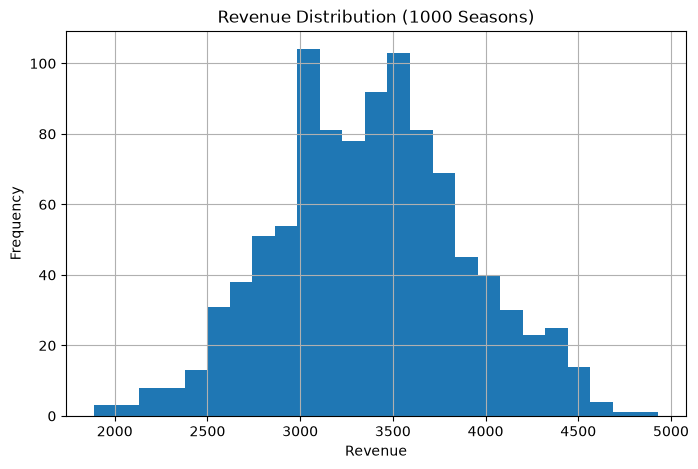

In [9]:
plt.figure(figsize=(8,5))

plt.hist(evaluation_results["Revenue"],bins=25)

plt.title("Revenue Distribution (1000 Seasons)")

plt.xlabel("Revenue")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

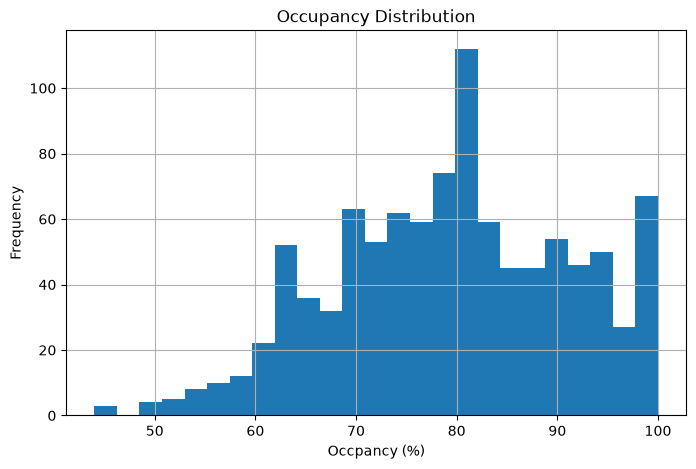

In [10]:
plt.figure(figsize=(8,5))

plt.hist(evaluation_results["Occupancy (%)"],bins=25)

plt.title("Occupancy Distribution")

plt.xlabel("Occpancy (%)")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

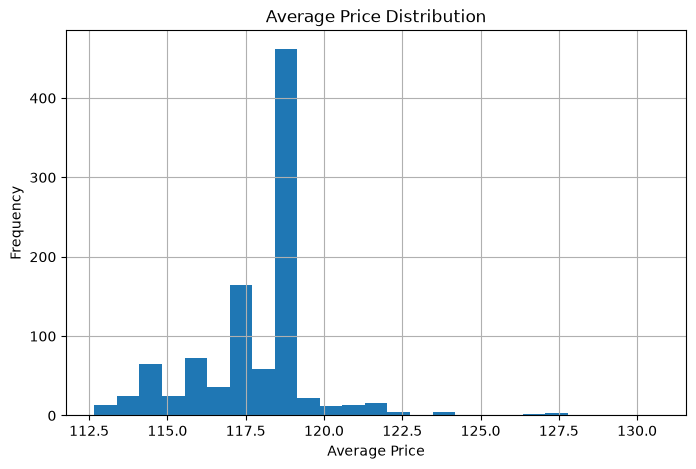

In [11]:
plt.figure(figsize=(8,5))

plt.hist(evaluation_results["Average Price"],bins=25)

plt.title("Average Price Distribution")

plt.xlabel("Average Price")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()